# Full-Dataset Model Comparison (De Chazal Split)

This notebook is the unified, full-dataset comparison of all the anomaly
detectors developed in the per-model notebooks (01-06). Unlike those notebooks,
which run on a small 5-record subset to validate the pipeline, this one uses the
**whole non-paced database** under the **De Chazal (2004) inter-patient split**:

- **Train**: normal beats from DS1 records only (semi-supervised setup).
- **Test**: all beats from DS2 records (normal + anomaly), completely unseen patients.

All models are scored by reconstruction/prediction error and share the same
evaluation protocol, so the numbers here are the reliable ones (the subset
results are volatile pipeline checks).

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import config
from utils import (
    load_all_mit_bih_records,
    create_beat_dataset,
    split_by_record_lists,
    evaluate_anomaly_detection,
)
from models import (
    PCAReconstructionAnomalyDetector,
    LSTMAutoencoderAnomalyDetector,
    VAEAnomalyDetector,
    CfCAutoencoderAnomalyDetector,
    ARMAModel,
)

## Experiment Configuration

`QUICK_TEST = True` runs a fast pipeline check (small subsample, few epochs).
Set it to **`False`** for the real full-dataset run (~40-55 min on a GTX 1650);
training shows a live progress bar (`verbose=True`).

In [2]:
QUICK_TEST = False  # <-- set to False for the full-dataset run

if QUICK_TEST:
    N_TRAIN_NORMAL = 3000          # cap on DS1 normal beats used for training
    BATCH_SIZE = 128
    EPOCHS_LSTM, EPOCHS_VAE, EPOCHS_CFC = 5, 5, 3
    ARMA_PER_CLASS = 300           # ARMA test beats per class
    print("QUICK_TEST: small subsample / few epochs (pipeline check, not final).")
else:
    N_TRAIN_NORMAL = None          # None = all DS1 normal beats (~45.8k)
    BATCH_SIZE = 256
    EPOCHS_LSTM, EPOCHS_VAE, EPOCHS_CFC = 30, 30, 20
    ARMA_PER_CLASS = None          # None = all DS2 anomalies + matched normals
    print("FULL run: all DS1 normals, full epochs (~40-55 min).")

FULL run: all DS1 normals, full epochs (~40-55 min).


## Load Data and Apply the De Chazal Split

In [3]:
records = load_all_mit_bih_records(config.MIT_BIH_PATH)
dataset = create_beat_dataset(records, normalize=True)

X = np.stack(dataset["signal"].values).astype("float32")
y = dataset["label"].values
metadata = dataset.drop(columns=["signal", "label"])

print("Total beats:", len(X))

Loading record 100...
Loading record 101...
Loading record 103...
Loading record 105...


Loading record 106...
Loading record 108...
Loading record 109...
Loading record 111...
Loading record 112...


Loading record 113...
Loading record 114...
Loading record 115...
Loading record 116...
Loading record 117...


Loading record 118...
Loading record 119...
Loading record 121...
Loading record 122...
Loading record 123...


Loading record 124...
Loading record 200...
Loading record 201...
Loading record 202...


...

Loading record 210...
Loading record 212...
Loading record 213...
Loading record 214...
Loading record 215...


Loading record 219...
Loading record 220...
Loading record 221...
Loading record 222...


Loading record 223...
Loading record 228...
Loading record 230...


Loading record 231...
Loading record 232...
Loading record 233...
Loading record 234...


Total beats: 100708


In [4]:
split = split_by_record_lists(X, y, metadata, config.DE_CHAZAL_DS1, config.DE_CHAZAL_DS2)

X_test, y_test = split["X_test"], split["y_test"]

# Training input: normal beats from DS1 only.
rng = np.random.default_rng(config.RANDOM_SEED)
X_train_normal = split["X_train"][split["y_train"] == 0]
rng.shuffle(X_train_normal)
if N_TRAIN_NORMAL is not None:
    X_train_normal = X_train_normal[:N_TRAIN_NORMAL]

print("DS1 train records:", len(config.DE_CHAZAL_DS1), "| DS2 test records:", len(config.DE_CHAZAL_DS2))
print("Normal training beats:", len(X_train_normal))
print("Test beats:", len(X_test),
      "| normal:", int((y_test == 0).sum()),
      "| anomaly:", int((y_test == 1).sum()))

DS1 train records:

 22 | DS2 test records: 22
Normal training beats: 45856
Test beats: 49698 | normal: 44246 | anomaly: 5452


## Train and Evaluate Each Model

Every model is trained on the DS1 normal beats and scored on the DS2 test set.
The threshold is the 95th percentile of the model's score on its normal training
beats. We collect, for each model: ROC-AUC and PR-AUC (threshold-independent
ranking quality) and precision / recall / F1 at the 95th-percentile operating
point.

ROC-AUC and PR-AUC don't always agree, and on this dataset they don't: DS2 is
only ~11% anomalies, and ROC-AUC is known to look overly optimistic on
imbalanced data (its false-positive-rate axis is dominated by the huge normal
class). PR-AUC focuses on the minority class instead, so it's the more
trustworthy metric here — keep that in mind when the two rankings disagree
below.

In [5]:
results = {}
curves = {}

def record_result(name, y_true, scores, threshold):
    """Evaluate a model and store its metrics and ROC/PR curve data."""
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)
    y_pred = (scores > threshold).astype(int)
    m = evaluate_anomaly_detection(y_true, y_pred, scores)
    results[name] = {
        "ROC-AUC": m["roc_auc"], "PR-AUC": m["pr_auc"],
        "precision": m["precision"], "recall": m["recall"], "f1": m["f1"],
    }
    curves[name] = (y_true, scores)
    print(f"{name:8} | ROC-AUC {m['roc_auc']:.3f} | PR-AUC {m['pr_auc']:.3f} | "
          f"P {m['precision']:.3f}  R {m['recall']:.3f}  F1 {m['f1']:.3f}")

### PCA (linear baseline)

In [6]:
pca = PCAReconstructionAnomalyDetector(
    n_components=8, threshold_percentile=95, random_state=config.RANDOM_SEED,
)
pca.fit(X_train_normal)
record_result("PCA", y_test, pca.anomaly_score(X_test), pca.threshold)

PCA      | ROC-AUC 0.728 | PR-AUC 0.190 | P 0.214  R 0.327  F1 0.259


### LSTM Autoencoder

In [7]:
lstm = LSTMAutoencoderAnomalyDetector(
    seq_len=config.BEAT_LEN, hidden_size=16, latent_dim=8,
    epochs=EPOCHS_LSTM, batch_size=BATCH_SIZE, random_state=config.RANDOM_SEED,
)
lstm.fit(X_train_normal, verbose=True)
record_result("LSTM-AE", y_test, lstm.anomaly_score(X_test), lstm.threshold)

Epoch 1/30 - loss: 0.0516


Epoch 2/30 - loss: 0.0159


Epoch 3/30 - loss: 0.0137


Epoch 4/30 - loss: 0.0122


Epoch 5/30 - loss: 0.0098


...

Epoch 27/30 - loss: 0.0043


Epoch 28/30 - loss: 0.0043


Epoch 29/30 - loss: 0.0042


Epoch 30/30 - loss: 0.0042


LSTM-AE  | ROC-AUC 0.688 | PR-AUC 0.283 | P 0.266  R 0.393  F1 0.317


### Variational Autoencoder

In [8]:
vae = VAEAnomalyDetector(
    input_dim=config.BEAT_LEN, hidden_size=64, latent_dim=8, beta=1.0,
    epochs=EPOCHS_VAE, batch_size=BATCH_SIZE, random_state=config.RANDOM_SEED,
)
vae.fit(X_train_normal, verbose=True)
record_result("VAE", y_test, vae.anomaly_score(X_test), vae.threshold)

Epoch 1/30 - loss: 7.0745


Epoch 2/30 - loss: 4.2463


Epoch 3/30 - loss: 3.4340


Epoch 4/30 - loss: 3.1770


Epoch 5/30 - loss: 3.0589


...

Epoch 27/30 - loss: 2.7892


Epoch 28/30 - loss: 2.7882


Epoch 29/30 - loss: 2.7837


Epoch 30/30 - loss: 2.7892


VAE      | ROC-AUC 0.698 | PR-AUC 0.267 | P 0.246  R 0.404  F1 0.306


### CfC (Liquid) Autoencoder

In [9]:
cfc = CfCAutoencoderAnomalyDetector(
    seq_len=config.BEAT_LEN, hidden_size=16, latent_dim=8,
    epochs=EPOCHS_CFC, batch_size=BATCH_SIZE, random_state=config.RANDOM_SEED,
)
cfc.fit(X_train_normal, verbose=True)
record_result("CfC-AE", y_test, cfc.anomaly_score(X_test), cfc.threshold)

Epoch 1/20 - loss: 0.0493


Epoch 2/20 - loss: 0.0143


Epoch 3/20 - loss: 0.0119


Epoch 4/20 - loss: 0.0122


Epoch 5/20 - loss: 0.0112


...

Epoch 17/20 - loss: 0.0119


Epoch 18/20 - loss: 0.0124


Epoch 19/20 - loss: 0.0114


Epoch 20/20 - loss: 0.0115


CfC-AE   | ROC-AUC 0.635 | PR-AUC 0.210 | P 0.260  R 0.232  F1 0.245


### ARMA (classical baseline)

ARMA fits one model per beat (~120 ms/beat), so scoring the whole DS2 test set
would take ~100 min. Since the ARMA score is independent per beat, we evaluate it
on a stratified sample of DS2 (all anomalies + a matched random sample of
normals), which is statistically representative. Its row in the table is
therefore computed on this sample, not on the full DS2.

In [10]:
arma = ARMAModel(
    p=config.ARIMA_P, d=config.ARIMA_D, q=config.ARIMA_Q, threshold_percentile=95,
)
arma.fit(X_train_normal[:300])  # threshold from a sample of normal training beats

anom_idx = np.where(y_test == 1)[0]
norm_idx = np.where(y_test == 0)[0]
rng_arma = np.random.default_rng(config.RANDOM_SEED)
rng_arma.shuffle(anom_idx)
rng_arma.shuffle(norm_idx)

n_per_class = len(anom_idx) if ARMA_PER_CLASS is None else ARMA_PER_CLASS
arma_idx = np.concatenate([anom_idx[:n_per_class], norm_idx[:n_per_class]])

X_arma, y_arma = X_test[arma_idx], y_test[arma_idx]
print(f"ARMA evaluated on {len(X_arma)} test beats "
      f"({int((y_arma==1).sum())} anomaly + {int((y_arma==0).sum())} normal)")
record_result("ARMA", y_arma, arma.anomaly_score(X_arma), arma.threshold)

ARMA evaluated on 10904 test beats (5452 anomaly + 5452 normal)


ARMA     | ROC-AUC 0.344 | PR-AUC 0.423 | P 0.384  R 0.041  F1 0.074


## Results Table

In [11]:
results_df = pd.DataFrame(results).T
results_df = results_df[["ROC-AUC", "PR-AUC", "precision", "recall", "f1"]]
# Sorted by PR-AUC, the more reliable metric on this imbalanced test set (see note above).
results_df = results_df.sort_values("PR-AUC", ascending=False)
display(results_df.style.format("{:.3f}").background_gradient(cmap="Greens", subset=["ROC-AUC", "PR-AUC", "f1"]))

,ROC-AUC,PR-AUC,precision,recall,f1
ARMA,0.344,0.423,0.384,0.041,0.074
LSTM-AE,0.688,0.283,0.266,0.393,0.317
VAE,0.698,0.267,0.246,0.404,0.306
CfC-AE,0.635,0.210,0.260,0.232,0.245
PCA,0.728,0.190,0.214,0.327,0.259


## ROC and Precision-Recall Curves

These curves are threshold-independent: they show how well each model's score
*ranks* anomalies, across all possible operating points.

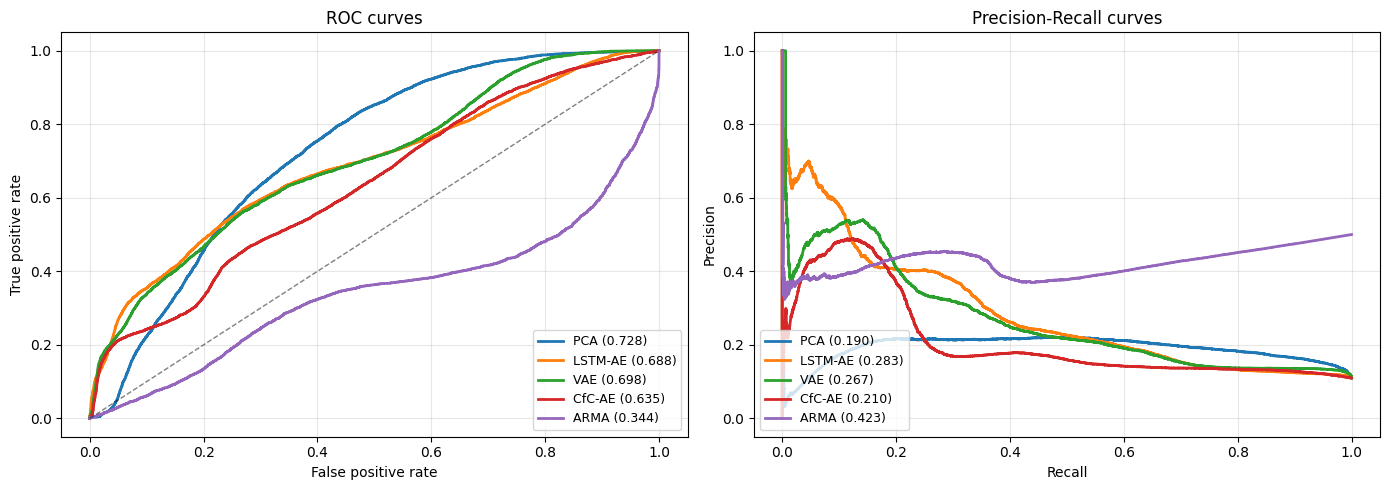

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, (yt, sc) in curves.items():
    fpr, tpr, _ = roc_curve(yt, sc)
    axes[0].plot(fpr, tpr, lw=2, label=f"{name} ({results[name]['ROC-AUC']:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curves")
axes[0].legend(loc="lower right", fontsize=9)
axes[0].grid(True, alpha=0.3)

for name, (yt, sc) in curves.items():
    prec, rec, _ = precision_recall_curve(yt, sc)
    axes[1].plot(rec, prec, lw=2, label=f"{name} ({results[name]['PR-AUC']:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curves")
axes[1].legend(loc="lower left", fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Score Distributions

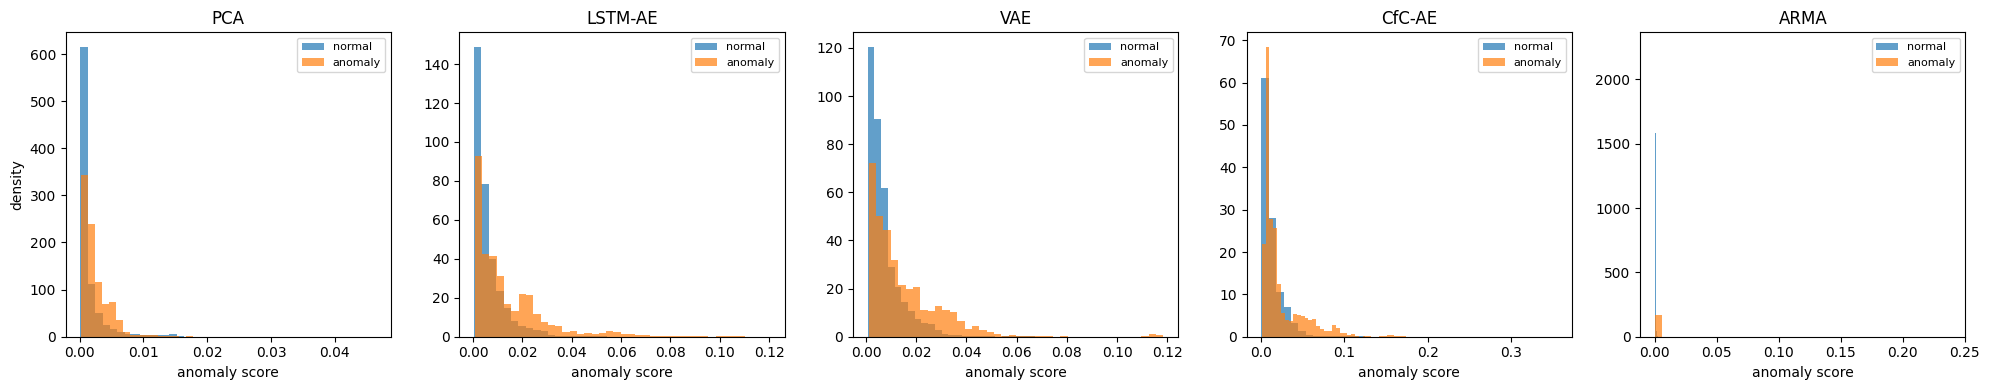

In [13]:
fig, axes = plt.subplots(1, len(curves), figsize=(4 * len(curves), 4), squeeze=False)

for ax, (name, (yt, sc)) in zip(axes[0], curves.items()):
    ax.hist(sc[yt == 0], bins=40, alpha=0.7, label="normal", density=True)
    ax.hist(sc[yt == 1], bins=40, alpha=0.7, label="anomaly", density=True)
    ax.set_title(name)
    ax.set_xlabel("anomaly score")
    ax.legend(fontsize=8)

axes[0][0].set_ylabel("density")
plt.tight_layout()
plt.show()

## Discussion

- These full-dataset, inter-patient results are the reliable ones. They are
  expected to be **much more modest** than the 5-record subset numbers, because
  the subset's test record (106) was dominated by easy high-energy ventricular
  beats, while DS2 includes subtle supraventricular (SVEB) anomalies.
- ROC-AUC / PR-AUC measure ranking quality independently of the threshold; the
  precision / recall / F1 columns reflect the fixed 95th-percentile operating
  point and depend on it.
- **The two rankings disagree, and that's the interesting part.** By ROC-AUC,
  PCA looks the strongest (0.728), with the deep autoencoders close behind. By
  PR-AUC — the metric that actually matters on an 11%-anomaly test set — the
  order flips: LSTM-AE (0.283) and VAE (0.267) clearly beat PCA (0.190), which
  is the weakest of the four reconstruction models. PCA separates the classes
  reasonably well overall, but it isn't as good at pushing anomalies to the very
  top of the ranking, which is exactly what PR-AUC rewards and what matters in
  practice when anomalies are rare.
- ARMA is a special case: its PR-AUC (0.423) is the highest in the table, but
  its recall is only 0.041 — it catches almost no anomalies, and the few it
  flags happen to be right. This isn't a sign that ARMA is secretly the best
  model; it's evaluated on a balanced sample (50% anomalies, since scoring the
  full 11%-anomaly DS2 would take ~100 minutes) rather than the same test
  distribution as the other models, so its PR-AUC sits on a different baseline
  and shouldn't be compared directly to theirs.
- The contamination analysis (notebook 08) studies how injecting anomalies into
  the training set degrades each model — a robustness comparison on top of this
  clean-training baseline.